# CNN(Convolutional Neural Network, 합성곱 신경망)

# Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import convolve, convolve2d, correlate, correlate2d
from sklearn.datasets import load_sample_image, load_sample_images
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import keras
import tensorflow as tf

# 1차원 합성곱 연산(1-D Convolution)

In [ ]:
x = np.arange(1, 6)
print(x)

[1 2 3 4 5]


In [ ]:
y = np.array([1, 2])
print(y)

[1 2]


In [ ]:
y_flip = np.flip(y)
print(y_flip)

[2 1]


## `concolve()` 함수

scipy 패키지의 convolve 함수는 y를 반전시키고 합성곱 연산을 수행.

In [ ]:
result = convolve(x, y, mode='valid')  # valid 모드 -> 배열 x보다 크기가 줄어듦.
print(result)

[ 4  7 10 13]


In [ ]:
result = convolve(x, y, mode='same')  # same 모드 -> 결과 배열은 x와 크기가 같음.
print(result)

[ 1  4  7 10 13]


In [ ]:
# full mode: 배열 x의 모든 원소가 합성곱 연산에 같은 비율로 참여하도록 패딩을 넣는 방법.
result = convolve(x, y, mode='full')
print(result)

[ 1  4  7 10 13 10]


## correlate() 함수

교차 상관(cross-correlate): scipy 패키지는 배열 y를 반전시키지 않고 배열 x와 합성곱 연산을 수행.

In [ ]:
result = correlate(x, y, mode='valid')
print(result)

[ 5  8 11 14]


In [ ]:
result = correlate(x, y, mode='same')
print(result)

[ 2  5  8 11 14]


In [ ]:
result = correlate(x, y, mode='full')
print(result)

[ 2  5  8 11 14  5]


# 2차원 합성곱(2-D Convolution)

In [ ]:
x = np.arange(1, 17).reshape((4, 4))
print(x)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]


In [ ]:
y = np.array([[0, 1], [2, 0]])
print(y)

[[0 1]
 [2 0]]


In [ ]:
y_flip = np.flip(y)
print(y_flip)

[[0 2]
 [1 0]]


## `convolve2d()` 함수

In [ ]:
result = convolve2d(x, y, mode='valid')
print(result)

[[ 9 12 15]
 [21 24 27]
 [33 36 39]]


In [ ]:
result = convolve2d(x, y, mode='same')
print(result)

[[ 0  1  2  3]
 [ 2  9 12 15]
 [10 21 24 27]
 [18 33 36 39]]


In [ ]:
result = convolve2d(x, y, mode='full')
print(result)

[[ 0  1  2  3  4]
 [ 2  9 12 15  8]
 [10 21 24 27 12]
 [18 33 36 39 16]
 [26 28 30 32  0]]


## `correlate2d()` 함수

In [ ]:
result = correlate2d(x, y, mode='valid')
print(result)

[[12 15 18]
 [24 27 30]
 [36 39 42]]


# 이미지 배열과 합성곱 연산

Python에서 이미지

*   숫자들의 배열
*   숫자들의 스케일:
    *   0 ~ 255 정수 스케일
    *   0.0 ~ 1.0 실수 스케일
*   배열의 모양
    *   흑백 이미지: (height, width) 모양의 2차원 배열.
    *   컬러 이미지: (height, width, channels) 모양의 3차원 배열.
        *   투명도가 없는 이미지: (height, width, 3). channels = rgb
        *   투명도가 있는 이미지: (height, width, 4). channels = rgba
    *   Keras 패키지에서는 합성곱 층에서 흑백 이미지를 사용할 때, 컬러 이미지처럼 3차원 배열을 사용.
        *   Keras 패키지는 흑백 이미지를 (height, width, 1) 모양의 3차원 배열로 취급.

In [ ]:
china = load_sample_image('china.jpg')

In [ ]:
china.shape

(427, 640, 3)

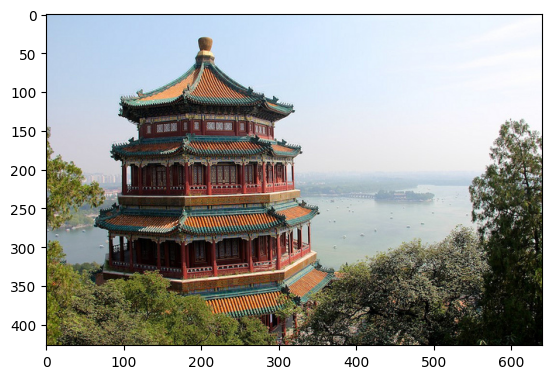

In [ ]:
plt.imshow(china)
plt.show()

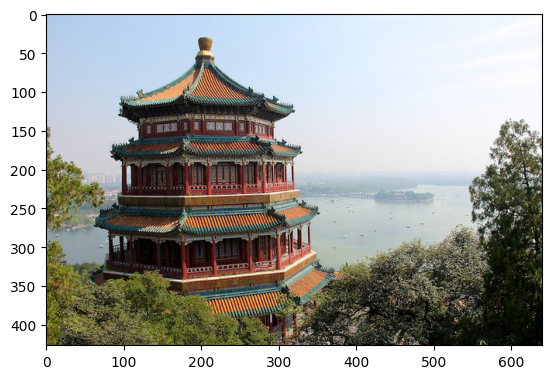

In [ ]:
china_scaled = china / 255
plt.imshow(china_scaled)
plt.show()

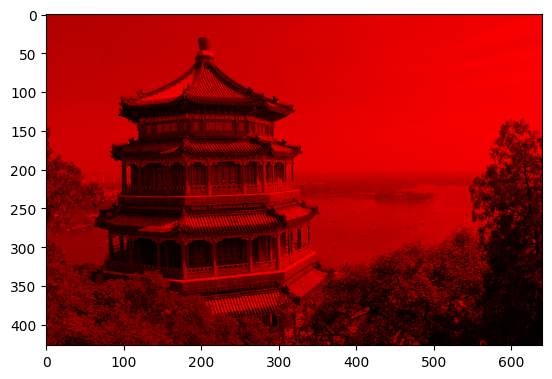

In [ ]:
china_scaled[:, :, [1, 2]] = 0.0
plt.imshow(china_scaled)
plt.show()

In [ ]:
filter = np.zeros(shape=(3, 3, 3))
filter[:, :, 0] = 1
result = convolve(china, filter, mode='same')
result = result.astype(np.uint8)  # np.uint8: 8bits unsigned integer(부호 없는 정수)
print(result.shape)

(427, 640, 3)


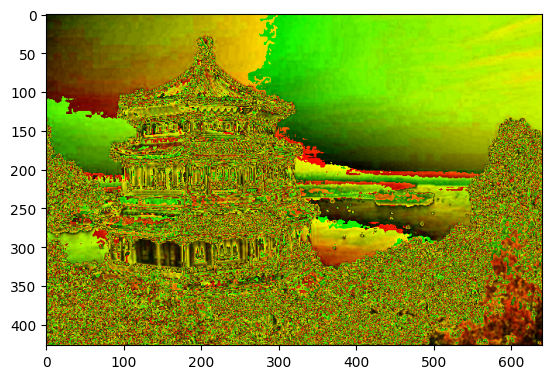

In [ ]:
plt.imshow(result)
plt.show()

# Pooling

In [ ]:
x = np.arange(1, 21).reshape((5, 4))
print(x)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]
 [17 18 19 20]]


In [ ]:
x = x.reshape((1, 5, 4, 1))

In [ ]:
print(x)

[[[[ 1]
   [ 2]
   [ 3]
   [ 4]]

  [[ 5]
   [ 6]
   [ 7]
   [ 8]]

  [[ 9]
   [10]
   [11]
   [12]]

  [[13]
   [14]
   [15]
   [16]]

  [[17]
   [18]
   [19]
   [20]]]]


## Max Pooling(최대 풀링)

필터링된 값들 중에서 최댓값을 선택하는 풀링 방식

In [ ]:
max_pooling = keras.layers.MaxPool2D()  # Max Pooling 연산을 수행하는 객체
x_pooled = max_pooling(x)  # Max Pooling 연산 수행
print(type(x_pooled))
print(x_pooled.shape)

<class 'tensorflow.python.framework.ops.EagerTensor'>
(1, 2, 2, 1)


In [ ]:
print(x_pooled.numpy().reshape((2, 2)))  # Tensor  --> ndarray 변환 --> 모양 변경

[[ 6  8]
 [14 16]]


## Avverage Pooling(평균 풀링)

필터링된 값들의 평균을 선택하는 풀링 방식.

In [ ]:
x = x.astype(np.float32)  # 배열 원소들의 타입을 32bit 실수 타입으로 변환
# TensorFlow는 암묵적인 타입 변환을 수행하지 않기 때문에.
avg_pooling = keras.layers.AveragePooling2D(pool_size=(2, 2))  # average pooling을 수행하는 객체
x_pooled = avg_pooling(x)
print(type(x_pooled))
print(x_pooled.shape)

<class 'tensorflow.python.framework.ops.EagerTensor'>
(1, 2, 2, 1)


In [ ]:
print(x_pooled.numpy().reshape((2, 2)))

[[ 3.5  5.5]
 [11.5 13.5]]


## 이미지 배열에서 풀링(Pooling)

이미지의 크기를 축소하는 효과

In [ ]:
flower = load_sample_image('flower.jpg')

In [ ]:
flower.shape  #> (height, width, channels)

(427, 640, 3)

In [ ]:
flower = flower / 255  # 픽셀 값들의 스케일을 0.0 ~ 1.0

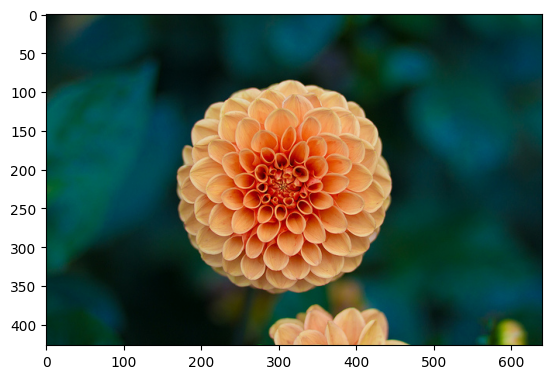

In [ ]:
plt.imshow(flower)
plt.show()

In [ ]:
x = flower.reshape((1, 427, 640, 3))

In [ ]:
max_pooling = keras.layers.MaxPool2D()
x_pooled = max_pooling(x)
print(x_pooled.shape)

(1, 213, 320, 3)


<function matplotlib.pyplot.show(close=None, block=None)>

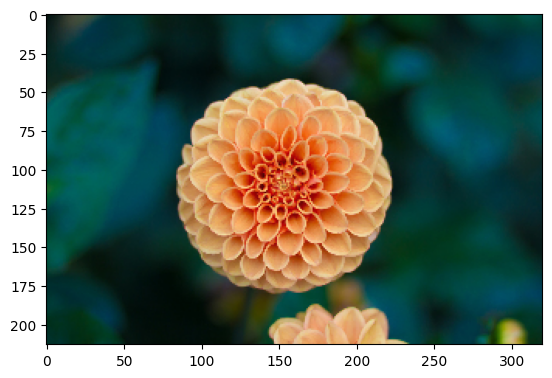

In [ ]:
img = x_pooled.numpy().reshape((213, 320, 3))  # x_pooled.numpy()[0]
plt.imshow(img)
plt.show

In [ ]:
avg_pooling = keras.layers.AveragePooling2D(pool_size=(2, 2))
x_pooled = avg_pooling(x)
print(x_pooled.shape)

(1, 213, 320, 3)


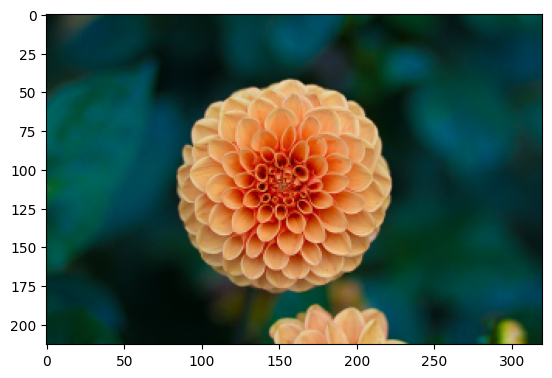

In [ ]:
img = x_pooled.numpy()[0]
plt.imshow(img)
plt.show()

# Fashion MNIST 데이터 셋

In [ ]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print('train set:', x_train_full.shape)  #> (n_samples, height, width)
print('test set:', x_test.shape)

train set: (60000, 28, 28)
test set: (10000, 28, 28)


*   신경망 훈련을 빠르게 하기 위해서 0 ~ 255 스케일을 0.0 ~ 1.0 스케일로 변환.
*   합성곱/풀링 연산을 할 수 있도록 하기 위해서 훈련 셋과 테스트 셋의 모양을 (n_samples, height, width, channels) 4차원으로 변환.


In [ ]:
# 픽셀 값 스케일링
x_train_full_scaled = x_train_full / 255
x_test_scaled = x_test / 255

In [ ]:
# 모양(shape) 변환
x_train_full_scaled = x_train_full_scaled.reshape((60_000, 28, 28, 1))
x_test_scaled = x_test_scaled.reshape((10_000, 28, 28, 1))

In [ ]:
# 전체 훈련 셋을 훈련/검증 셋으로 분리
x_train, x_val, y_train, y_val = train_test_split(x_train_full_scaled, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42)

In [ ]:
x_train.shape

(48000, 28, 28, 1)

# 합성곱 신경망(CNN, Convolutional Neural Network)

Input --> Conv2D --> MaxPool2D --> Conv2D --> MaxPool2D --> Flatten --> Dense --> Dropout --> Output

*   filter(필터): 합성곱 층에서의 유닛(unit).
*   kernel(커널): 필터의 값들. 합성곱 연산에서 곱해지는 가중치들.
*   kernel_size: 필터의 크기.
*   feature map(특성 맵): 합성곱 연산의 결과로 나오는 출력.
*   padding(패딩): 입력 배열 주위에 가상의 값(0)을 채우는 것.
    *   same padding: 입력 배열과 특성 맵의 크기를 같게 만들어 주는 패딩 방식.
    *   valid padding: 패딩 없이 합성곱을 수행. 특성 맵의 크기는 입력 배열의 크기보다 작아짐.
    *   full padding: 입력 배열의 모든 값들이 합성곱 연산에서 동일한 비율로 연산에 참여하도록 하는 패딩 방식.
*   stride(보폭): 필터를 이동시키는 크기. CNN에서는 일반적으로 stride=1로 설정.
    *   CNN에서는 합성곱 층의 stride를 크게 해서 이미지 사이즈를 줄이는 방법보다는, 풀링 층을 사용해서 이미지의 크기를 줄이는 방법을 선호.
*   pooling(풀링)
    *   가중치(kernel 값)가 없고, 일반적으로 풀링 크기와 보폭 크기를 같게 함.
    *   일반적으로 패딩을 사용하지 않음. padding='valid'.
    *   max pooling(최대 풀링): 필터 안의 입력 값들 중에서 최댓값을 선택.
    *   average pooling(평균 풀링): 필터 안의 입력 값들의 평균값을 계산.
    *   평균 풀링은 특성 맵의 중요한 정보들을 희석시킬 수 있기 때문에, 대부분 최대 풀링을 선호.

In [ ]:
# Sequential 객체 생성
model = keras.Sequential()

In [ ]:
# 입력층(input layer)
inputs = keras.Input(shape=(28, 28, 1))  #> shape = (height, width, channels), 흑백이미지 channel=1
model.add(inputs)

In [ ]:
# 합성곱 층(convolutional layer)
conv_1 = keras.layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu')
model.add(conv_1)

In [ ]:
# 최대 풀링 층(max pooling layer)
max_pool_1 = keras.layers.MaxPool2D()
model.add(max_pool_1)

In [ ]:
conv_2 = keras.layers.Conv2D(filters=64, kernel_size=3, padding='same', activation='relu')
model.add(conv_2)

In [ ]:
max_pool_2 = keras.layers.MaxPool2D()
model.add(max_pool_2)

In [ ]:
# flatten layer: 특성 맵을 2차원 배열로 변환.
model.add(keras.layers.Flatten())

In [ ]:
# 밀집 층(dense layer)
dense_1 = keras.layers.Dense(units=100, activation='relu')
model.add(dense_1)

In [ ]:
# drop-out layer(과대적합을 줄이기 위해서)
model.add(keras.layers.Dropout(rate=0.3))

In [ ]:
# 출력층(output layer)
dense_2 = keras.layers.Dense(units=10, activation='softmax')
model.add(dense_2)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

모델 파라미터(가중치, weights)

*   첫번째 Conv2D layer(filters=32, kernel_size=3)
    *   입력 배열의 모양: (28, 28, 1)
    *   필터 1개의 모양: (3, 3, 1)
    *   필터 1개의 가중치: 3 x 3 x 1(kernel) + 1(bias) = 10
    *   필터 32개 - 총 가중치 개수 = 10 * 32 = 320
*   MaxPool2D layer는 필터 안에서 최댓값을 찾아서 출력으로 내보내면 되기 때문에, 학습을 통해서 업데이트하는 가중치(모델 파라미터)가 없음.
*   두번째 Conv2D layer(filter=64, kernel_size=3)
    *   입력 배열의 모양: (14, 14, 32)
    *   필터 1개의 모양: (3, 3, 32)
    *   필터 1개의 가중치: kernel(3 * 3 * 32) + bias(1)
    *   필터 64개 - 총 가중치 개수 = (3 * 3 * 32 + 1) * 64
*   첫번째 밀집층(units=100)
    *   입력 배열의 모양: (7 * 7 * 64, )
    *   유닛 1개의 가중치: kernel(7 * 7 * 64) + bias(1)
    *   유닛 100개의 가중치 (7 * 7 * 64 + 1) * 100

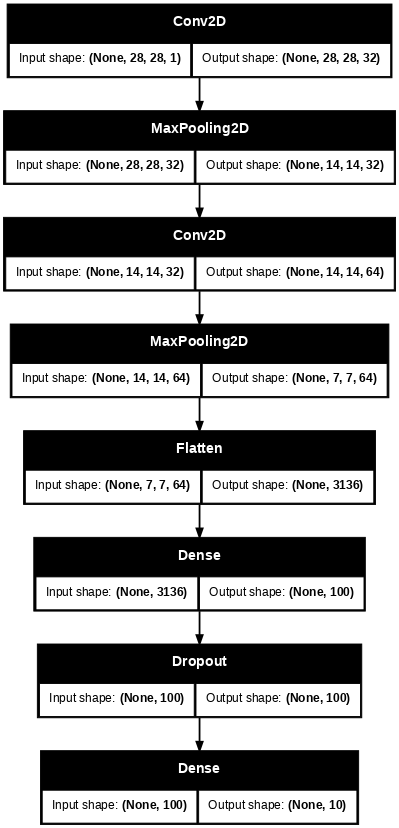

In [ ]:
keras.utils.plot_model(model, dpi=64, show_shapes=True)

In [ ]:
# 모델 컴파일
model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.sparse_categorical_crossentropy,
              metrics=[keras.metrics.sparse_categorical_accuracy])

In [ ]:
# 최적의 모델을 저장하기 위한 파일 위치
dir_path = '/content/drive/MyDrive/lab_ml'
file_path = dir_path + '/cnn_best_model.keras'

# 콜백 생성
checkpoint_cb = keras.callbacks.ModelCheckpoint(filepath=file_path, save_best_only=True)
early_stop_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

In [ ]:
# 모델 훈련
result = model.fit(x=x_train, y=y_train, batch_size=64, epochs=1_000,
                   validation_data=[x_val, y_val],
                   callbacks=[checkpoint_cb, early_stop_cb])

Epoch 1/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 59s 77ms/step - loss: 0.5408 - sparse_categorical_accuracy: 0.8068 - val_loss: 0.3265 - val_sparse_categorical_accuracy: 0.8803
Epoch 2/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 58s 77ms/step - loss: 0.3524 - sparse_categorical_accuracy: 0.8750 - val_loss: 0.2891 - val_sparse_categorical_accuracy: 0.8951
Epoch 3/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 54s 71ms/step - loss: 0.3024 - sparse_categorical_accuracy: 0.8903 - val_loss: 0.2532 - val_sparse_categorical_accuracy: 0.9082
Epoch 4/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 56s 74ms/step - loss: 0.2680 - sparse_categorical_accuracy: 0.9031 - val_loss: 0.2437 - val_sparse_categorical_accuracy: 0.9119
Epoch 5/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step - loss: 0.2465 - sparse_categorical_accuracy: 0.9103 - val_loss: 0.2312 - val_sparse_categorical_accuracy: 0.9162
Epoch 6/1000
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step - loss: 0.2264 - sparse_categorical_accuracy: 0.9161 - val_loss: 0.2341 - val_sparse_categoric

In [ ]:
# 손실 그래프
epochs = result.epoch
epochs

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

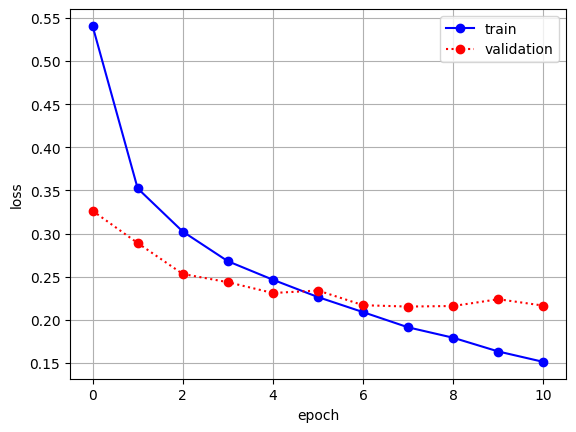

In [ ]:
# 손실 그래프
epochs = result.epoch  # 에포크 인덱스
history = result.history  # 각 에포크에서 훈련/검증 셋의 손실 & 정확도를 저장하고 있는 dict
plt.plot(epochs, history['loss'], 'bo-', label='train')
plt.plot(epochs, history['val_loss'], 'ro:', label='validation')
plt.legend()
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [ ]:
# 훈련 셋 평가
model.evaluate(x=x_train, y=y_train)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 0.1439 - sparse_categorical_accuracy: 0.9477


[0.14387670159339905, 0.9476875066757202]

In [ ]:
# 검증 셋 평가
model.evaluate(x=x_val, y=y_val)

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2154 - sparse_categorical_accuracy: 0.9246


[0.21543383598327637, 0.9245833158493042]

검증 셋 혼동 행렬(confusion matrix)

In [ ]:
val_predicts = model.predict(x=x_val)

375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step


In [ ]:
val_predicts.shape  #> (12_000, 10): 12,000개 검증 셋의 10개의 확률

(12000, 10)

In [ ]:
val_pred_labels = np.argmax(val_predicts, axis=1)
val_pred_labels.shape  #> (12_000,): 12,000개 검증 셋의 예측 레이블들.

(12000,)

In [ ]:
conf_mat = confusion_matrix(y_true=y_val, y_pred=val_pred_labels)
conf_mat

array([[1094,    1,    7,   17,    3,    0,   73,    0,    5,    0],
       [   1, 1184,    2,   12,    0,    0,    0,    0,    1,    0],
       [  22,    0, 1049,   16,   60,    0,   49,    0,    4,    0],
       [  26,    9,    3, 1108,   36,    0,   17,    0,    1,    0],
       [   2,    4,   64,   36, 1031,    0,   63,    0,    0,    0],
       [   0,    0,    0,    0,    0, 1174,    0,   14,    1,   11],
       [ 117,    2,   65,   22,   60,    0,  930,    0,    4,    0],
       [   0,    0,    0,    0,    0,   13,    0, 1167,    0,   20],
       [   1,    1,    0,    3,    2,    2,    3,    2, 1186,    0],
       [   0,    0,    0,    0,    0,    2,    0,   26,    0, 1172]])

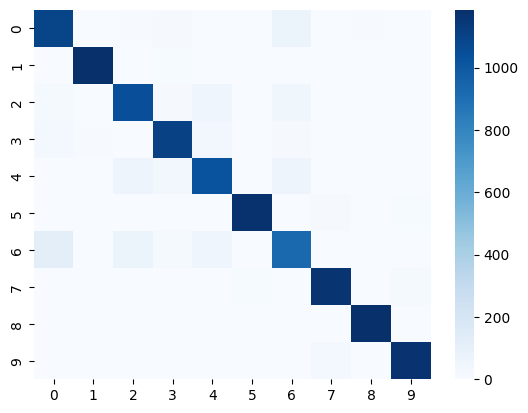

In [ ]:
sns.heatmap(data=conf_mat, cmap='Blues')
plt.show()

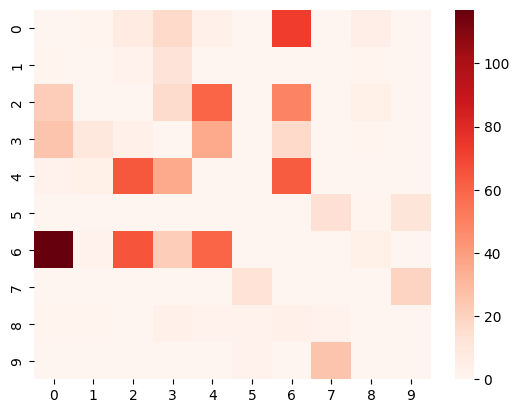

In [ ]:
# 예측이 틀린 부분을 진하게 보기 위해서
np.fill_diagonal(conf_mat, 0)
sns.heatmap(conf_mat, cmap='Reds')
plt.show()

Fashion MNIST 데이터셋 클래스들:
티셔츠(0), 바지(1), 스웨터(2), 드레스(3), 코트(4), 샌달(5), 셔츠(6), 스니커즈(7), 가방(8), 앵클 부츠(9)

# 합성곱 시각화

In [ ]:
sample_images = load_sample_images()

In [ ]:
print(type(sample_images))  #> Bunch

<class 'sklearn.utils._bunch.Bunch'>


In [ ]:
sample_images.keys()

dict_keys(['images', 'filenames', 'DESCR'])

In [ ]:
images = sample_images['images']  # sample_images.images: 이미지들의 리스트

In [ ]:
images

[array([[[174, 201, 231],
         [174, 201, 231],
         [174, 201, 231],
         ...,
         [250, 251, 255],
         [250, 251, 255],
         [250, 251, 255]],
 
        [[172, 199, 229],
         [173, 200, 230],
         [173, 200, 230],
         ...,
         [251, 252, 255],
         [251, 252, 255],
         [251, 252, 255]],
 
        [[174, 201, 231],
         [174, 201, 231],
         [174, 201, 231],
         ...,
         [252, 253, 255],
         [252, 253, 255],
         [252, 253, 255]],
 
        ...,
 
        [[ 88,  80,   7],
         [147, 138,  69],
         [122, 116,  38],
         ...,
         [ 39,  42,  33],
         [  8,  14,   2],
         [  6,  12,   0]],
 
        [[122, 112,  41],
         [129, 120,  53],
         [118, 112,  36],
         ...,
         [  9,  12,   3],
         [  9,  15,   3],
         [ 16,  24,   9]],
 
        [[116, 103,  35],
         [104,  93,  31],
         [108, 102,  28],
         ...,
         [ 43,  49,  39],
  

array([[[ 2, 19, 13],
        [ 3, 18, 13],
        [ 7, 20, 13],
        ...,
        [ 1, 77, 64],
        [ 0, 76, 64],
        [ 0, 75, 63]],

       [[ 1, 18, 12],
        [ 3, 18, 13],
        [ 7, 20, 13],
        ...,
        [ 0, 76, 64],
        [ 1, 74, 65],
        [ 1, 74, 65]],

       [[ 2, 17, 12],
        [ 6, 19, 12],
        [ 7, 20, 13],
        ...,
        [ 1, 74, 65],
        [ 1, 74, 67],
        [ 1, 74, 67]],

       ...,

       [[ 0, 46, 40],
        [ 1, 48, 40],
        [ 1, 47, 37],
        ...,
        [ 5, 44, 26],
        [ 6, 43, 26],
        [ 7, 44, 27]],

       [[ 0, 47, 41],
        [ 1, 48, 40],
        [ 1, 47, 37],
        ...,
        [ 6, 45, 27],
        [ 7, 44, 27],
        [ 7, 44, 27]],

       [[ 0, 47, 41],
        [ 1, 48, 40],
        [ 0, 46, 36],
        ...,
        [ 7, 46, 28],
        [ 8, 45, 28],
        [ 9, 43, 27]]], dtype=uint8)
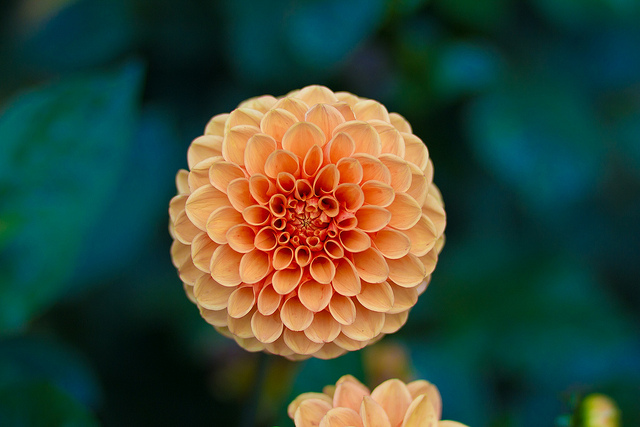

In [ ]:
images[1]
# images: (427, 640, 3) 모양의 ndarray 2개를 갖는 파이썬 리스트(list)

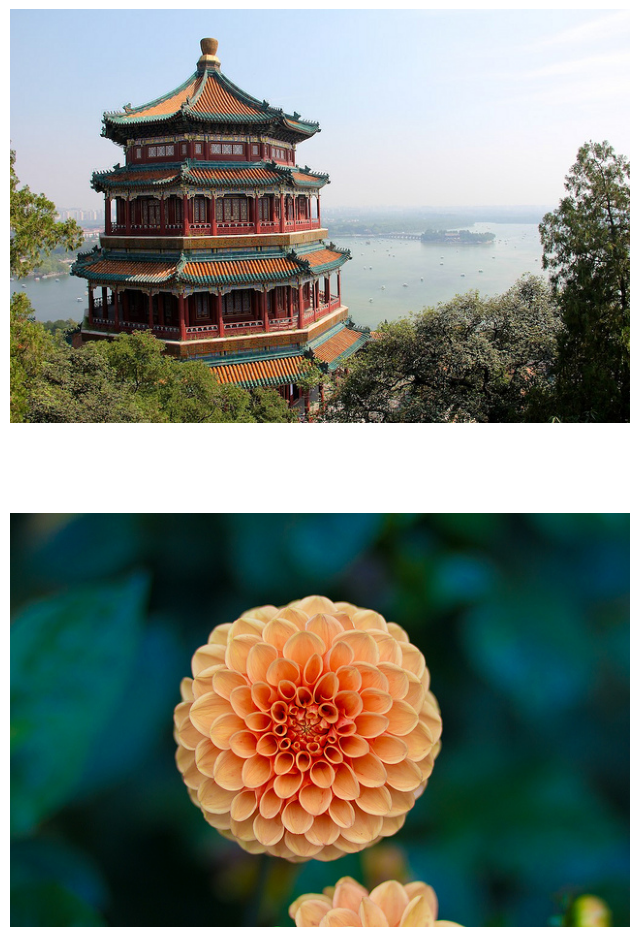

In [ ]:
fig, axes = plt.subplots(nrows=2, figsize=(8, 12))
for i in range(2):
    axes[i].imshow(images[i])
    axes[i].axis('off')
plt.show()

In [ ]:
# 이미지 자르기 - 이미지 정중앙에서 70x120 크기로 이미지를 자름.
# images 모양: (2, 427, 640, 3) - (n_samples, height, width, channels)
images_crop = keras.layers.CenterCrop(height=70, width=120)(images)
images_crop.shape

TensorShape([2, 70, 120, 3])

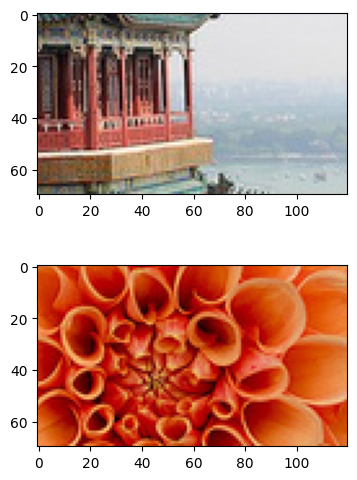

In [ ]:
fig, axes = plt.subplots(nrows=2, figsize=(4, 6))
for i in range(2):
    axes[i].imshow(tf.cast(images_crop[i], dtype=tf.uint8))
plt.show()

In [ ]:
# 이미지 픽셀 스케일링: 0 ~ 255 스케일을 0.0 ~ 1.0 스케일로 변환
images_scaled = keras.layers.Rescaling(scale=1.0/255)(images_crop)
images_scaled.shape

TensorShape([2, 70, 120, 3])

In [ ]:
# 2D 합성곱을 수행하기 위한 필터(배열): (7, 7, 3) 모양의 필터 2개
filters = np.zeros(shape=(7, 7, 3, 2))  #> (kernel_height, kernel_width, kernel_depth, n_kernels)

# 첫번째 합성곱 필터는 가운데 수직선의 값을 1로, 나머지는 0 그대로.
filters[:, 3, :, 0] = 1

# 두번째 합성곱 필터는 가운데 수평선의 값을 1로, 나머지는 0 그대로.
filters[3, :, :, 1] = 1

In [ ]:
# 2D 합성곱 연산 수행
feature_maps = tf.nn.conv2d(input=images_scaled, filters=filters, strides=1, padding='SAME')
feature_maps.shape  #> (2, 70, 120, 2)

TensorShape([2, 70, 120, 2])

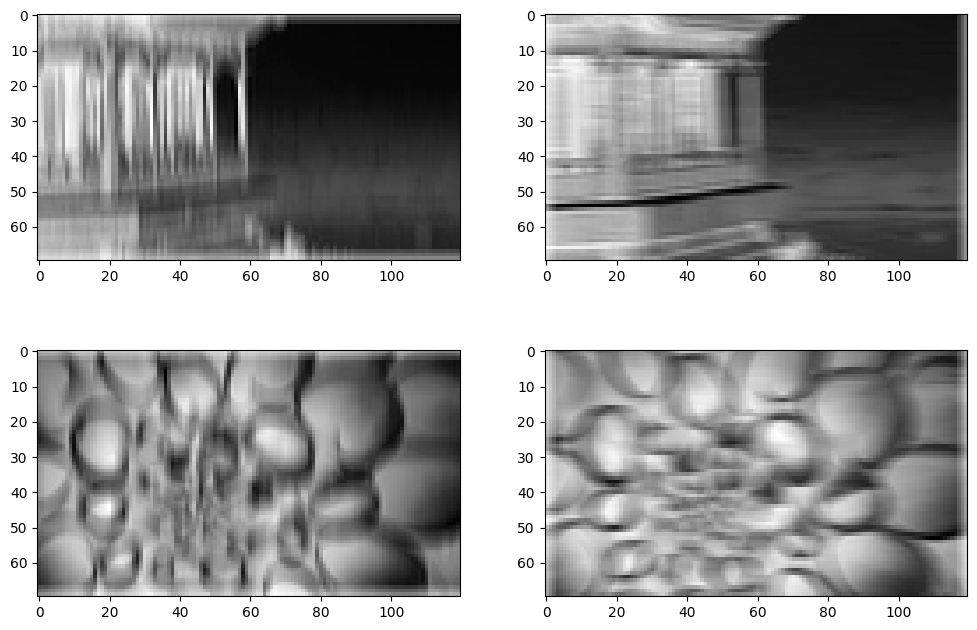

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
for i in range(2):
    for j in range(2):
        axes[i, j].imshow(feature_maps[i, :, :, j], cmap=plt.cm.binary)

plt.show()

# 훈련된 CNN에서 합성곱 층 시각화

In [ ]:
model  #> Sequential - CNN 모델

<Sequential name=sequential, built=True>

In [ ]:
model.layers  # 각 층들을 순서대로 저장한 리스트

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d_2, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_3, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

In [ ]:
model.layers[0]  # CNN 모델의 첫번째 계층 - Conv2D

<Conv2D name=conv2d, built=True>

In [ ]:
model.layers[0].output  #> 첫번째 합성곱 층의 출력

<KerasTensor shape=(None, 28, 28, 32), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1>

In [ ]:
model.inputs

[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor>]

In [ ]:
# 입력층과 첫번째 합성곱 층만 연결한 모델을 생성
conv1_output = keras.Model(model.inputs, model.layers[0].output)

In [ ]:
x_test_scaled[0].shape

(28, 28, 1)

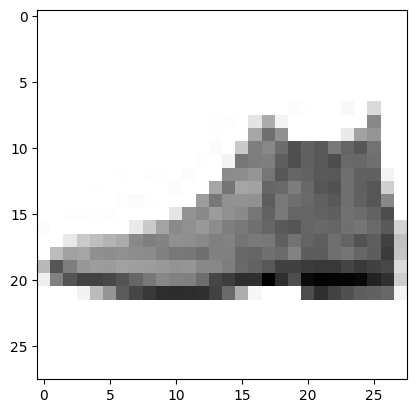

In [ ]:
plt.imshow(x_test_scaled[0].reshape((28, 28)), cmap=plt.cm.binary)
plt.show()

In [ ]:
x_test_scaled[:1].shape
#> 합성곱 층에서 predict 메서드의 아규먼트의 모양은 (n_samples, height, width, channels)

(1, 28, 28, 1)

In [ ]:
feature_maps = conv1_output.predict(x_test_scaled[:1])
feature_maps.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


(1, 28, 28, 32)

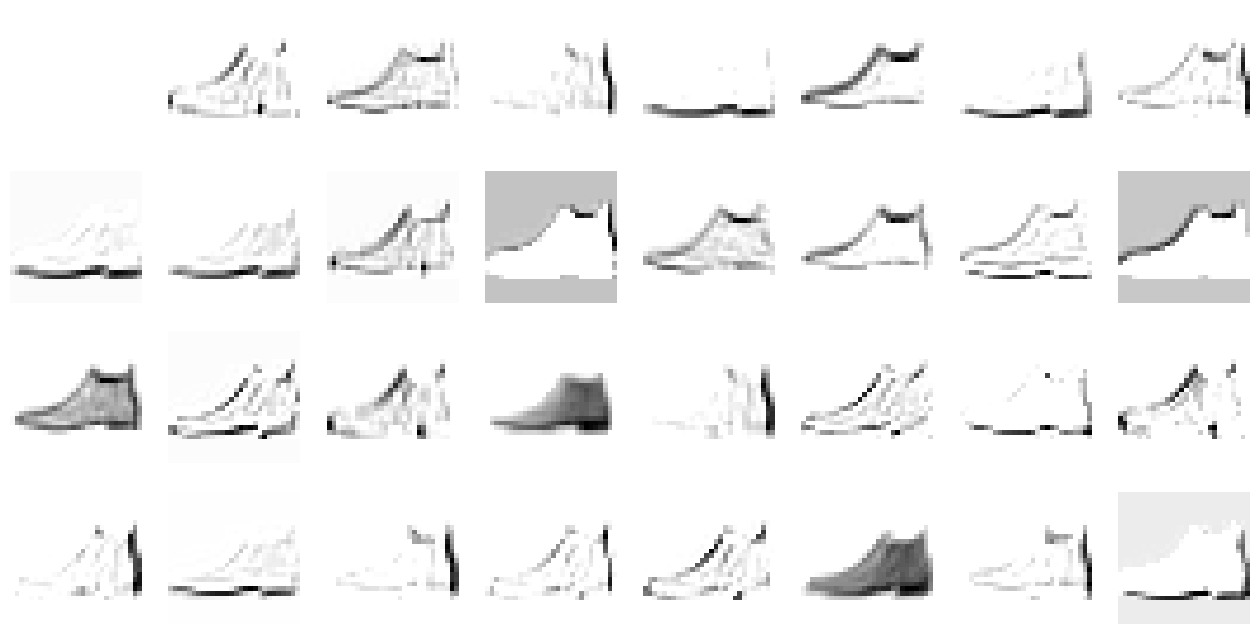

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=8, figsize=(16, 8))
for i in range(4):
    for j in range(8):
        idx = i * 8 + j
        axes[i, j].imshow(feature_maps[0, :, :, idx], cmap=plt.cm.binary)
        axes[i, j].axis('off')
plt.show()